# Table of Contents
1. [Overview](#Overview)
2. [Data Loading](#Data-Loading)
3. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
4. [Feature Engineering](#Feature-Engineering)
5. [Modeling](#Modeling)
6. [Evaluation](#Evaluation)
7. [Next Steps](#Next-Steps)

In [1]:
import sys
import os
import pandas as pd
import matplotlib as plt
# Prevent truncation of columns in notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Go up to the project root (assuming you're in /notebooks)
project_root = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from src.historical_loader import load_fpl_history

df = load_fpl_history('../data/raw/Fantasy-Premier-League/data')
df.head()

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,creativity,dribbles,ea_index,element,errors_leading_to_goal,errors_leading_to_goal_attempt,fixture,fouls,goals_conceded,goals_scored,ict_index,id,influence,key_passes,kickoff_time,kickoff_time_formatted,loaned_in,loaned_out,minutes,offside,open_play_crosses,opponent_team,own_goals,penalties_conceded,penalties_missed,penalties_saved,recoveries,red_cards,round,saves,selected,tackled,tackles,target_missed,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,winning_goals,yellow_cards,GW,season,position,team,xP,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts
0,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,10,0.0,0,0,0.0,454.0,0.0,0.0,2016-08-15T19:00:00Z,15 Aug 20:00,0.0,0.0,0,0.0,0.0,4,0,0.0,0,0,0.0,0,1,0,14023,0.0,0.0,0.0,1.0,2.0,0.0,0,0,0,0,55,False,0.0,0,1,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron_Lennon,0,3.0,0.0,0.0,0,6,0,1.0,2.0,0.3,0.0,0.0,142,0.0,0.0,3,0.0,0,0,0.9,142.0,8.2,0.0,2016-08-13T14:00:00Z,13 Aug 15:00,0.0,0.0,15,0.0,0.0,17,0,0.0,0,0,1.0,0,1,0,13918,1.0,2.0,0.0,1.0,1.0,0.0,1,0,0,0,60,True,0.0,0,1,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aaron_Ramsey,0,26.0,0.0,0.0,0,5,0,2.0,22.0,4.9,1.0,0.0,16,0.0,0.0,8,0.0,3,0,3.0,16.0,2.2,0.0,2016-08-14T15:00:00Z,14 Aug 16:00,0.0,0.0,60,0.0,0.0,9,0,0.0,0,0,2.0,0,1,0,163170,2.0,0.0,1.0,4.0,3.0,23.0,2,0,0,0,80,True,0.0,0,1,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abdoulaye_Doucouré,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,482,0.0,0.0,7,0.0,0,0,0.0,482.0,0.0,0.0,2016-08-13T14:00:00Z,13 Aug 15:00,0.0,0.0,0,0.0,0.0,13,0,0.0,0,0,0.0,0,1,0,1051,0.0,0.0,0.0,1.0,1.0,0.0,0,0,0,0,50,False,0.0,0,1,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Abdul Rahman_Baba,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,80,0.0,0.0,10,0.0,0,0,0.0,80.0,0.0,0.0,2016-08-15T19:00:00Z,15 Aug 20:00,0.0,0.0,0,0.0,0.0,20,0,0.0,0,0,0.0,0,1,0,1243,0.0,0.0,0.0,1.0,2.0,0.0,0,0,0,0,55,True,0.0,0,1,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
df.team.value_counts(dropna=False)

NaN               90496
Chelsea            5600
Brighton           5598
Wolves             5440
Man Utd            5433
Aston Villa        5430
Arsenal            5338
Everton            5295
Newcastle          5240
Spurs              5239
Liverpool          5238
Crystal Palace     4999
Man City           4677
West Ham           4542
Brentford          4129
Fulham             4063
Burnley            3878
Leeds              3866
Nott'm Forest      3636
Southampton        3627
Leicester          3567
Bournemouth        2745
Sheffield Utd      2582
Luton              1695
Watford            1678
Norwich            1295
West Brom          1212
Name: team, dtype: int64

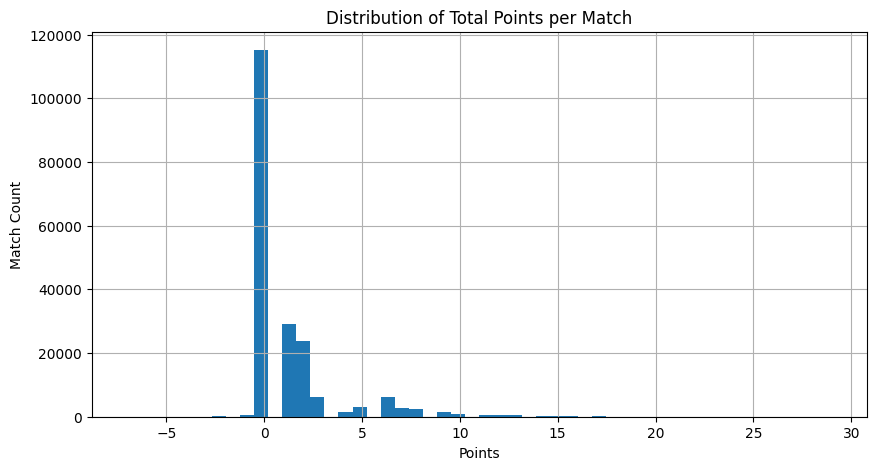

In [4]:
import matplotlib.pyplot as plt

df['total_points'].hist(bins=50, figsize=(10, 5))
plt.title('Distribution of Total Points per Match')
plt.xlabel('Points')
plt.ylabel('Match Count')
plt.show()

In [5]:
df.groupby(['season', 'name'])['total_points'].sum().sort_values(ascending=False).groupby('season').head(5)


season   name                         
2017-18  Mohamed_Salah                    303
2022-23  Erling Haaland                   272
2021-22  Mohamed Salah                    265
2016-17  Alexis_Sánchez                   264
2022-23  Harry Kane                       263
2018-19  Mohamed_Salah_253                259
2021-22  Heung-Min Son                    258
2019-20  Kevin_De Bruyne_215              251
2020-21  Bruno Miguel Borges Fernandes    244
2023-24  Cole Palmer                      244
2020-21  Harry Kane                       242
2022-23  Mohamed Salah                    239
2018-19  Eden_Hazard_122                  238
         Raheem_Sterling_270              234
2019-20  Mohamed_Salah_191                233
2018-19  Sadio_Mané_251                   231
2020-21  Mohamed Salah                    231
2023-24  Phil Foden                       230
2017-18  Raheem_Sterling                  229
2020-21  Heung-Min Son                    228
2023-24  Ollie Watkins                   

In [6]:
df.season.value_counts()

2023-24    29725
2022-23    26505
2021-22    25447
2020-21    24365
2016-17    23679
2019-20    22560
2017-18    22467
2018-19    21790
Name: season, dtype: int64

In [7]:
# Summary of missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("🔍 Columns with missing values:")
print(missing)

🔍 Columns with missing values:
starts                             140308
expected_goals_conceded            140308
expected_goals                     140308
expected_goal_involvements         140308
expected_assists                   140308
loaned_out                         128602
winning_goals                      128602
target_missed                      128602
tackles                            128602
tackled                            128602
recoveries                         128602
penalties_conceded                 128602
big_chances_created                128602
offside                            128602
attempted_passes                   128602
loaned_in                          128602
kickoff_time_formatted             128602
big_chances_missed                 128602
clearances_blocks_interceptions    128602
completed_passes                   128602
dribbles                           128602
ea_index                           128602
errors_leading_to_goal             128602
err

In [9]:
# Filter rows where creativity or influence is greater than 0
non_zero_creativity = df[df['creativity'] > 0].groupby('name')['GW'].min()
non_zero_influence = df[df['influence'] > 0].groupby('name')['GW'].min()

# Combine results into a single DataFrame for comparison
result = pd.DataFrame({
    'First GW with Creativity': non_zero_creativity,
    'First GW with Influence': non_zero_influence
})

print(result)

                        First GW with Creativity  First GW with Influence
name                                                                     
Aaron Connolly                               1.0                      1.0
Aaron Cresswell                              1.0                      1.0
Aaron Hickey                                 1.0                      1.0
Aaron Lennon                                 3.0                      3.0
Aaron Ramsdale                               3.0                      1.0
...                                          ...                      ...
Ãaglar SÃ¶yÃ¼ncÃ¼                           1.0                      1.0
Ãaglar_SÃ¶yÃ¼ncÃ¼_164                       1.0                      1.0
Ãrjan_Nyland_27                             NaN                     12.0
ÄorÄe PetroviÄ                            NaN                     21.0
Çaglar_Söyüncü_515                          33.0                     33.0

[2809 rows x 2 columns]


## Number of Players in all seasons

In [14]:
df.columns

Index(['name', 'assists', 'attempted_passes', 'big_chances_created', 'big_chances_missed', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'completed_passes', 'creativity', 'dribbles', 'ea_index', 'element', 'errors_leading_to_goal', 'errors_leading_to_goal_attempt', 'fixture', 'fouls', 'goals_conceded', 'goals_scored', 'ict_index', 'id', 'influence', 'key_passes', 'kickoff_time', 'kickoff_time_formatted', 'loaned_in', 'loaned_out', 'minutes', 'offside', 'open_play_crosses', 'opponent_team', 'own_goals', 'penalties_conceded', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'round', 'saves', 'selected', 'tackled', 'tackles', 'target_missed', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'winning_goals', 'yellow_cards', 'GW', 'season', 'position', 'team', 'xP', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'starts',
 

In [50]:
df.name.nunique()

3806

In [49]:
# Group by seaon and check players who played
(df.groupby(['name'])['minutes'].sum()==0).reset_index()['minutes'].value_counts()

False    2853
True      953
Name: minutes, dtype: int64

953 players played 0 minutes

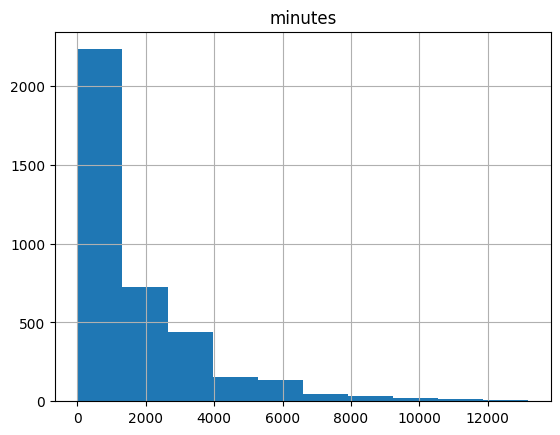

In [58]:
(df.groupby(['name'])['minutes'].sum()).reset_index().hist();

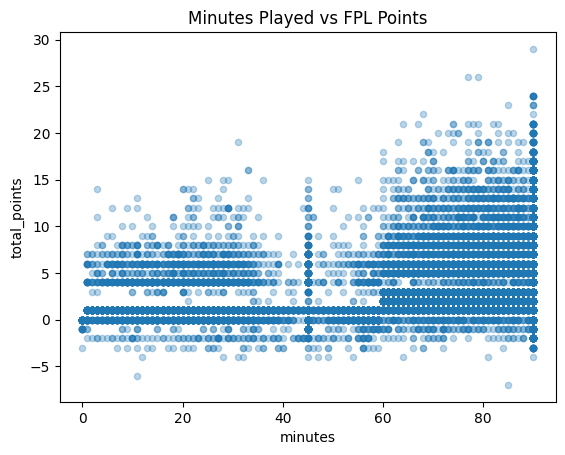

,minutes,total_points
minutes,1.000000,0.639429
total_points,0.639429,1.000000


In [59]:
import matplotlib.pyplot as plt
df.plot.scatter(x='minutes', y='total_points', alpha=0.3)
plt.title("Minutes Played vs FPL Points")
plt.show()
df[['minutes', 'total_points']].corr()


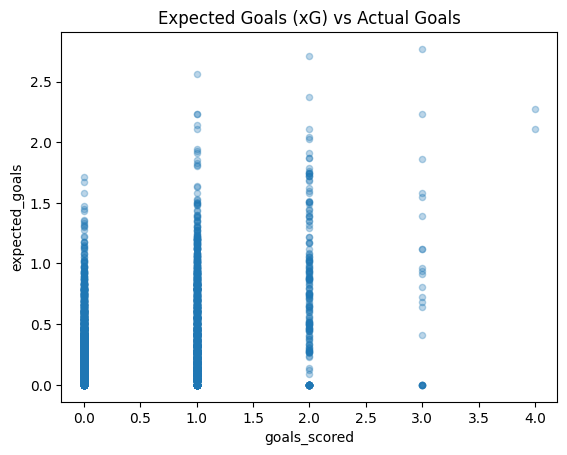

,expected_goals,goals_scored
expected_goals,1.000000,0.581162
goals_scored,0.581162,1.000000


In [63]:
# Assumes 'xG' and 'goals_scored' columns exist
df.plot.scatter(x='goals_scored', y='expected_goals', alpha=0.3)
plt.title("Expected Goals (xG) vs Actual Goals")
plt.show()
df[['expected_goals', 'goals_scored']].corr()


In [65]:
# Create features for team win / D / L with goal difference as well 

In [64]:
# If 'team_result' is 'W', 'D', 'L', or similar, or derive it:
df['team_win'] = df['team_result'] == 'W'
df.groupby('team_win')['total_points'].mean().plot(kind='bar')
plt.title("Average FPL Points: Win vs Not Win")
plt.show()


KeyError: 'team_result'

# Rolling Average of Total Points

In [11]:
def calculate_rolling_average(df, column, window=3):
    """
    Calculate rolling averages for a specified column over the past `window` gameweeks.

    Parameters:
    df (pd.DataFrame): The input dataframe containing gameweek data.
    column (str): The column name for which to calculate the rolling average.
    window (int): The rolling window size (default is 3).

    Returns:
    pd.DataFrame: DataFrame with an additional column for rolling averages.
    """
    df = df.sort_values(by=['season', 'name', 'GW'])  # Ensure proper sorting
    df[f'{column}_rolling_avg'] = (
        df.groupby(['season', 'name'])[column]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    return df




In [12]:
# Example usage:
df = calculate_rolling_average(df, 'total_points', window=3)
df.head(20)

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,creativity,dribbles,ea_index,element,errors_leading_to_goal,errors_leading_to_goal_attempt,fixture,fouls,goals_conceded,goals_scored,ict_index,id,influence,key_passes,kickoff_time,kickoff_time_formatted,loaned_in,loaned_out,minutes,offside,open_play_crosses,opponent_team,own_goals,penalties_conceded,penalties_missed,penalties_saved,recoveries,red_cards,round,saves,selected,tackled,tackles,target_missed,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,winning_goals,yellow_cards,GW,season,position,team,xP,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,total_points_rolling_avg
0,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,10,0.0,0,0,0.0,454.0,0.0,0.0,2016-08-15T19:00:00Z,15 Aug 20:00,0.0,0.0,0,0.0,0.0,4,0,0.0,0,0,0.0,0,1,0,14023,0.0,0.0,0.0,1.0,2.0,0.0,0,0,0,0,55,False,0.0,0,1,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
6611,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,20,0.0,0,0,0.0,979.0,0.0,0.0,2016-08-21T15:00:00Z,21 Aug 16:00,0.0,0.0,0,0.0,0.0,2,0,0.0,0,0,0.0,0,2,0,11531,0.0,0.0,0.0,0.0,1.0,0.0,0,-3002,79,3081,55,True,0.0,0,2,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
13127,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,29,0.0,0,0,0.0,1519.0,0.0,0.0,2016-08-28T15:00:00Z,28 Aug 16:00,0.0,0.0,0,0.0,0.0,10,0,0.0,0,0,0.0,0,3,0,9587,0.0,0.0,0.0,1.0,3.0,0.0,0,-2053,28,2081,54,False,0.0,0,3,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
20153,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,38,0.0,0,0,0.0,2069.0,0.0,0.0,2016-09-10T14:00:00Z,10 Sep 15:00,0.0,0.0,0,0.0,0.0,18,0,0.0,0,0,0.0,0,4,0,8427,0.0,0.0,0.0,4.0,2.0,0.0,0,-1221,45,1266,54,True,0.0,0,4,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
20734,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,46,0.0,0,0,0.0,2650.0,0.0,0.0,2016-09-17T14:00:00Z,17 Sep 15:00,0.0,0.0,0,0.0,0.0,19,0,0.0,0,0,0.0,0,5,0,7933,0.0,0.0,0.0,2.0,4.0,0.0,0,-520,29,549,54,False,0.0,0,5,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
21318,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,59,0.0,0,0,0.0,3234.0,0.0,0.0,2016-09-25T15:00:00Z,25 Sep 16:00,0.0,0.0,0,0.0,0.0,13,0,0.0,0,0,0.0,0,6,0,7450,0.0,0.0,0.0,3.0,0.0,0.0,0,-500,20,520,54,True,0.0,0,6,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
21904,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,70,0.0,0,0,0.0,3820.0,0.0,0.0,2016-10-01T14:00:00Z,01 Oct 15:00,0.0,0.0,0,0.0,0.0,12,0,0.0,0,0,0.0,0,7,0,7199,0.0,0.0,0.0,1.0,1.0,0.0,0,-285,40,325,53,True,0.0,0,7,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
22493,Aaron_Cresswell,1,20.0,1.0,0.0,0,23,1,4.0,12.0,25.1,0.0,0.0,454,0.0,0.0,74,2.0,0,0,4.8,4409.0,16.4,2.0,2016-10-15T16:30:00Z,15 Oct 17:30,0.0,0.0,74,1.0,1.0,5,0,0.0,0,0,3.0,1,8,0,7862,0.0,0.0,1.0,1.0,0.0,6.0,6,468,678,210,53,False,0.0,0,8,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
23085,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,90,0.0,0,0,0.0,5001.0,0.0,0.0,2016-10-22T14:00:00Z,22 Oct 15:00,0.0,0.0,0,0.0,0.0,15,0,0.0,0,0,0.0,0,9,0,9957,0.0,0.0,0.0,0.0,1.0,0.0,0,1813,2313,500,53,True,0.0,0,9,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
524,Aaron_Cresswell,0,41.0,0.0,0.0,0,12,0,1.0,35.0,7.9,0.0,0.0,454,0.0,0.0,92,0.0,2,0,1.3,5595.0,5.4,0.0,2016-10-30T13:30:00Z,30 Oct 13:30,0.0,0.0,90,0.0,1.0,6,0,0.0,0,0,3.0,0,10,0,12638,0.0,0.0,0.0,0.0,2.0,0.0,1,2432,2697,265,53,False,0.0,0,10,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.333333
